In [1]:
import numpy as np

class Perceptron:

    def __init__(self, num_inputs, learning_rate=0.1):
        self.weights = np.zeros(num_inputs)
        self.bias = 0
        self.learning_rate = learning_rate

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        summation = np.dot(inputs, self.weights) + self.bias
        return self.activation(summation)

    def fit(self, X, y, epochs=20):

        for epoch in range(epochs):
            for inputs, target in zip(X, y):

                prediction = self.predict(inputs)

                error = target - prediction

                self.weights += self.learning_rate * error * inputs
                self.bias += self.learning_rate * error

    def accuracy(self, X, y):
        predictions = [self.predict(x) for x in X]
        return np.mean(predictions == y)

In [4]:
#AND GATE
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

and_model = Perceptron(num_inputs=2, learning_rate=0.1)
and_model.fit(X_and, y_and, epochs=20)

print("AND Gate Predictions")
for x in X_and:
    print(x,"->",and_model.predict(x))

print("Accuracy =", and_model.accuracy(X_and,y_and)*100,"%")

AND Gate Predictions
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1
Accuracy = 100.0 %


In [5]:
#OR GATE
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

or_model = Perceptron(num_inputs=2, learning_rate=0.1)
or_model.fit(X_or, y_or, epochs=20)

print("OR Gate Predictions")
for x in X_or:
    print(x,"->",or_model.predict(x))

print("Accuracy =", or_model.accuracy(X_or,y_or)*100,"%")

OR Gate Predictions
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1
Accuracy = 100.0 %


In [6]:
#RANDOM DATASET
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [9]:
#GENERATE DATASET
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [10]:
#SPILIT DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
#FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#TRAIN MODEL
model = Perceptron(num_inputs=2, learning_rate=0.1)
model.fit(X_train, y_train, epochs=100)

In [14]:
#PREDICT
predictions = []
for x in X_test:
    predictions.append(model.predict(x))

In [15]:
#ACCURACY
accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy =", accuracy*100,"%")

Model Accuracy = 87.0 %


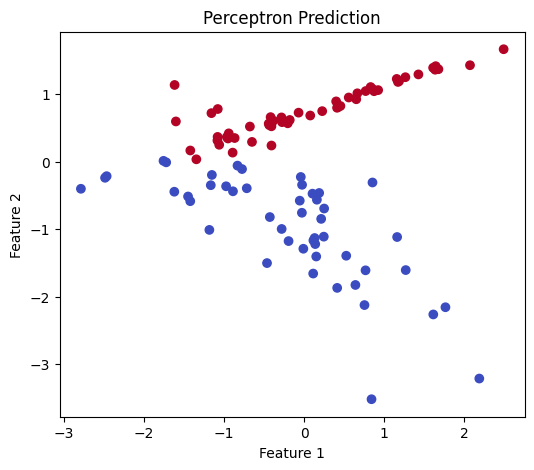

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=predictions,
    cmap='coolwarm'
)
plt.title("Perceptron Prediction")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()